# 7. 지시를 따르도록 미세 튜닝하기

지금까지 LLM 구조를 구현하고, 사전 훈련을 수행하고, 오픈 AI에서 사전 훈련한 가중치를 모델에 로드했다. 그런 다음 스팸 메시지와 스팸이 아닌 메시지를 구별하는 분류 작업을 통해 LLM을 미세 튜닝했다. 이제 사람의 지시를 따르도록 LLM을 미세 튜닝해보자. 지시 미세 튜닝은 챗봇 애플리케이션, 개인 비서, 그 외 다른 대화식 작업을 위한 LLM을 개발하는 데 필요한 주요 기술 중 하나이다.

## 7.1 지시 미세 튜닝 소개
LLM을 사전 훈련 하는 것은 한 번에 한 단어씩 생성하는 방법을 배우는 것이다. 이렇게 만들어진 사전 훈련된 LLM은 텍스트 완성 능력이 있다. 즉, 텍스트의 일부를 입력 받아 문장을 완성하거나 문단 전체를 작성할 수 있다. 하지만 사전 훈련된 LLM은 '이 텍스트의 문법을 고쳐줘' 도는 '이 텍스트를 수동태로 바꿔줘'와 같은 구체적인 명령을 잘 수행하지 못한다. 나중에 **지시 미세 튜닝(instruction fine-tuning)** 또는 **지도 학습 지시 미세 튜닝(supervised instruction fine-tuning)** 을 위해 사전 훈련된 LLM을 로드하여 사용하는 구체적인 예제를 살펴볼 것이다.

이 장에서는 지시를 따르고 기대하는 응답을 생성하도록 LLM의 능력을 향상시키는 데 중점을 둔다.

## 7.2 지도 학습 미세 튜닝을 위해 데이터셋 준비하기
사전 훈련된 LLM을 지시 미세 튜닝하기 위해 데이터셋을 다운로드하고 전처리해 보자. 이 데이터셋은 지시-응답 쌍 1,100개로 구성되어 있다.

다음 코드는 이 데이터셋을 다운로드하는 함수를 정의하고 실행한다. 이 데이터는 비교적 작은 크기의 JSON 파일이다.

In [3]:
import json
import os
import urllib


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r") as file:
        data = json.load(file)

    return data


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rickiepark/llm-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("샘플 개수:", len(data))

샘플 개수: 1100


JSON 파일로 로드한 data 리스트는 지시 데이터셋에 있는 1,100개의 샘플을 담고 있다.

샘플 하나를 출력하여 어떤 형태로 저장되어 있는지 확인해보자.

In [4]:
print("샘플 예시:\n", data[50])

샘플 예시:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


여기서 볼 수 있듯이 샘플은 'instruction', 'input', 'output' 키로 구성된 파이썬 딕셔너리이다.

또 다른 샘플을 확인해보자.

In [5]:
print("다른 샘플:\n", data[999])

다른 샘플:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


출력된 내용을 보면 'input' 항목이 비어있는 것을 알 수 있다.

지시 미세 튜닝은 JSON 파일에서 추출한 샘플처럼 입력-출력 쌍으로 구성된 데이터셋에서 모델을 훈련한다. LLM을 위해 샘플을 포맷팅하는 방법은 여러 가지이다.

그림은 유명한 LLM인 알파카(Alpaca)와 Phi-3을 훈련하는 데 사용된 두 가지 포맷이다. 이를 종종 **프폼프트 스타일(prompt style)** 이라 부른다.

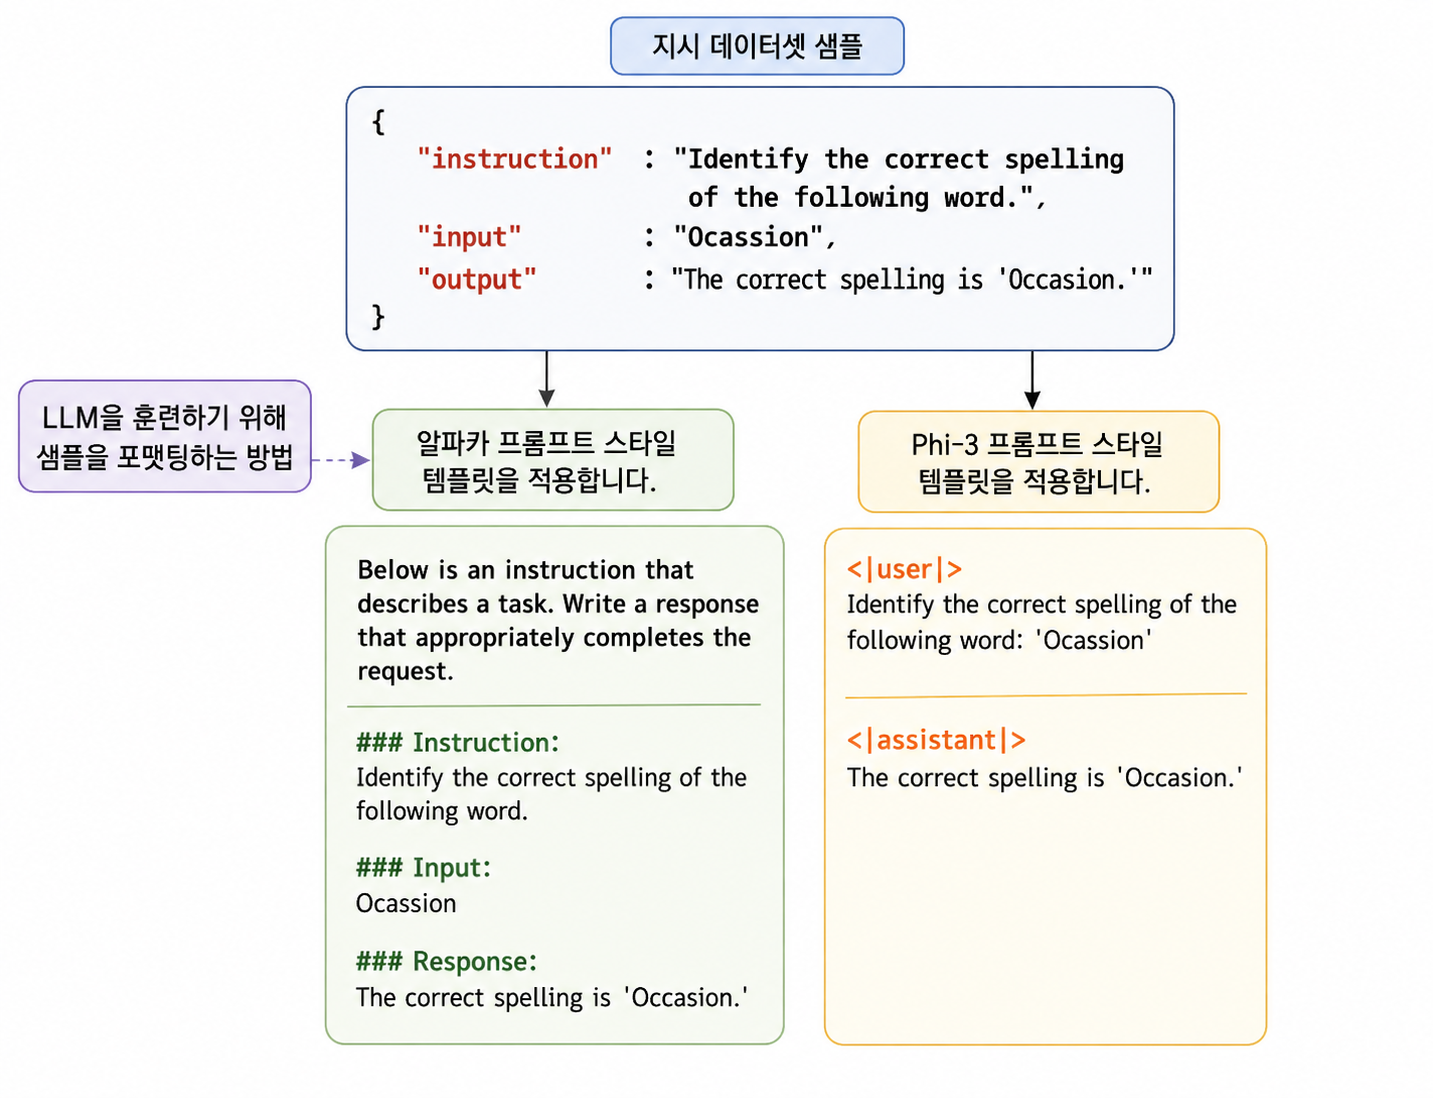



알파카는 초기 LLM 중 하나로 지시 미세 튜닝 과정에 대한 내용이 공개되어 있다. 마이크로소프트에서 개발한 Phi-3는 프롬프트 스타일의 다양성을 보여 주기 위해 예로 들었다. 이 장의 나머지 부분에서는 알파카 프롬프트 스타일을 적용한다. 알파카 스타일이 초기 미세 튜닝 방법을 정의하는 데 크게 기여를 했고 인기가 많은 포맷이기 때문이다.

data 리스트의 항목을 알파카 스타일의 포맷으로 변환하는 format_input 함수를 정의해보자.

In [6]:
def format_input(entry):
  instruction_text = (
      f"Below is an instruction that describes a task. "
      "Write a response that appropriately completes the request.\n\n"
      f"### Instruction:\n{entry['instruction']}"
  )

  input_text = (
      f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
  )

  return instruction_text + input_text

format_input 함수는 딕셔너리 entry를 입력으로 받아 포맷팅된 문자열을 만든다.

앞서 로드한 데이터셋에 있는 샘플 하나(data[50])로 이 함수를 테스트해보자.

In [7]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input+desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


format_input 함수는 'input' 필드가 비어 있는 경우 ### Input 섹션을 건너뛴다.


앞서 보았던 data[999]로 format_input 함수르 테스트해보자.

In [8]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


다음 절에서 파이토치 데이터 로더를 만들기 전에 이전 장에서 스팸 분류 데이터셋으로 했던 것처럼 데이터셋을 훈련 세트, 검증 세트, 테스트 세트로 나눈다.

다음 코드는 비율에 따라 데이터셋을 나누는 과정이다.

In [9]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion:train_portion+test_portion]
val_data = data[train_portion+test_portion:]

print("훈련 세트 크기:", len(train_data))
print("검증 세트 크기:", len(val_data))
print("테스트 세트 크기:", len(test_data))

훈련 세트 크기: 935
검증 세트 크기: 55
테스트 세트 크기: 110


데이터셋을 다운로드해서 분할하였고 프롬프트 스타일 템플릿에 대해 이해했으므로, 이제 지시 미세 튜닝 과정의 핵심 부분을 구현할 차례이다. 다음 절에서는 LLM을 미세 튜닝하기 위해 훈련 배치를 구성하는 방법을 알아보자.

## 7.3 훈련 배치 만들기
지시 미세 튜닝 과정의 구현 단계의 다음 스텝은 훈련 배치를 효과적으로 구성하는 것이다. 이를 통해 미세 튜닝 과정에서 모델에게 포맷팅된 훈련 배치를 제공할 수 있다.

이전 장에서 파이토치 DataLoader 클래스로 훈련 배치를 자동으로 만들었다. 이 클래스는 샘플 리스트를 배치로 묶어 주는 기본 콜레이트(collate) 함수를 사용한다. 콜레이트 함수는 훈련하는 동안 개별 데이터 샘플의 리스트를 받아 하나의 배치로 합쳐 모델을 효과적으로 처리할 수 있도록 한다.


하지만 지시 미세 튜닝을 위한 배치 구성은 조금 더 복잡하기 때문에 DataLoader에 적용할 사용자 정의 콜레이트 함수를 정의해야 한다. 이 콜레이트 함수를 구현하여 지시 미세 튜닝 데이터셋에서 요구되는 작업과 포맷팅을 처리한다.

다음은 배치 구성 과정을 구현하기 위한 5개의 세부 단계이다.
1. 프롬프트 템플릿을 사용해 데이터 포맷팅 하기: 입력을 지시-응답 템플릿으로 포맷팅한다.
2. 포맷팅된 데이터 토큰화하기: 지시-응답 샘플을 토큰 ID로 변환한다.
3. 패딩 토큰을 사용해 동일한 길이로 맞추기: 샘플이 동일한 길이가 되도록 텍스트 종료 토큰(50256)으로 패딩을 추가한다.
4. 훈련을 위해 타깃 토큰 ID 만들기: 모델이 학습하기 위해 타깃 토큰 ID의 리스트를 만든다. (입력에서 한 토큰씩 이동한 후에 패딩 토큰을 추가하여 만든다.)
5. 패딩 토큰을 플레이스홀더 토큰으로 바꾸기: 훈련 손실 계산에서 제외하기 위해 패딩 토큰을 -100으로 바꾼다.

먼저 1단계와 2단계에서 데이터셋의 모든 샘플에 format_input을 적용하고 토큰화하는 InstructionDataset 클래스를 구현한다.

In [10]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
  def __init__(self, data, tokenizer):
    self.data = data
    self.encoded_texts = []
    for entry in data: # 텍스트를 토큰화한다.
      instruction_plus_input = format_input(entry)
      response_text = f"\n\n### Response:\n{entry['output']}"
      full_text = instruction_plus_input + response_text
      self.encoded_texts.append(
          tokenizer.encode(full_text)
      )

  def __getitem__(self, index):
    return self.encoded_texts[index]

  def __len__(self):
    return len(self.data)

분류 미세 튜닝에 사용했던 방식과 비슷하게 여러 개의 훈련 샘플을 배치로 묶어 훈련 속도를 높이는게 좋다. 이렇게 하려면 모든 입력의 길이가 같도록 패딩을 추가해야 한다. 분류 미세 튜닝에서처럼 <|endoftext|> 토큰을 추가하는 대신에 <|endoftext|>에 해당하는 토큰 ID를 토큰화된 입력에 바로 추가할 수 있다. 토크나이저의 .encode 메서드를 사용해 <|endoftext|> 토큰의 ID를 확인해보자.

In [11]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


3단계로 넘어가 조금 더 복잡한 작업을 수행하기 위해 데이터 로더에 전달할 사용자 정의 콜레이트 함수를 작성해보자. 이 콜레이트 함수는 배치에 있는 훈련 샘플의 길이가 동일하도록 패딩을 추가한다.

사용자 정의 콜레이트 함수로 패딩 처리를 구현해보자.

In [12]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
  batch_max_length = max(len(item)+1 for item in batch) # 배치에서 가장 긴 시퀀스를 찾는다.
  inputs_lst = []

  for item in batch: # 입력에 패딩을 추가한다.
    new_item = item.copy()
    new_item += [pad_token_id]

    padded = (
        new_item + [pad_token_id] *
        (batch_max_length - len(new_item))
    )
    inputs = torch.tensor(padded[:-1])
    inputs_lst.append(inputs)

  inputs_tensor = torch.stack(inputs_lst).to(device) # 입력의 리스트를 텐서로 변환하고 타깃 장치로 전송한다.
  return inputs_tensor


서로 다른 세 가지 입력을 전달하여 동일한 길이로 패딩한 다음에 배치로 만들어보자.

In [13]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
    inputs_1,
    inputs_2,
    inputs_3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


출력을 보면 5개의 토큰 ID를 가진 가장 긴 inputs_1의 길이에 맞춰 모든 입력에 패딩이 추가되었다.

입력 리스트로부터 배치를 만드는 첫 번째 사용자 정의 콜레이트 함수를 만들었다. 하지만 앞서 배웠듯이 입력 토큰 ID에 해당하는 타깃 토큰 ID로 구성된 배치도 만들어야 한다. 타깃 ID는 모델이 생성해야 할 것을 나타내며 훈련 과정에서 손실을 계산하여 가중치를 업데이트하기 위해 중요하다.

이 사용자 정의 콜레이트 함수를 입력 토큰 ID와 함께 타깃 토큰 ID를 반환하도록 수정한다. 다음은 입력 토큰 ID에서 타깃 토큰 ID를 생성하는 콜레이트 함수이다.

In [14]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
  batch_max_length = max(len(item)+1 for item in batch)
  inputs_lst, targets_lst = [], []

  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]

    padded=(
        new_item + [pad_token_id] *
        (batch_max_length - len(new_item))
    )

    inputs = torch.tensor(padded[:-1]) # 입력에서 마지막 토큰을 삭제한다.
    targets = torch.tensor(padded[1:])
    inputs_lst.append(inputs)
    targets_lst.append(targets)

  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(targets_lst).to(device)
  return inputs_tensor, targets_tensor

inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


다음 단계에서는 모든 패딩 토큰을 플레이스홀더 값 -100으로 바꾼다. 이 특별한 값은 훈련 손실 계산에서 패딩 토큰을 제외시킨다. 따라서 의미 있는 데이터만 모델 학습에 영향을 미친다.

하지만 ID가 50256인 텍스트 종료 토큰 하나는 남겨 둔다. 이를 남겨 두면 LLM이 지시에 응답할 때 텍스트 종료 토큰을 언제 생성할지 학습할 수 있다.

다음 코드는 사용자 콜레이트 함수를 수정하여 타깃 리스트에서 ID가 50256인 토큰을 -100으로 바꾼다. 또한 allowed_max_length 매개변수를 추가하여 선택적으로 샘플의 길이를 제한하도록 만든다. 사용하려는 데이터셋에 GPT-2 모델이 지원하는 1,024 토큰의 문맥 길이보다 긴 샘플이 있을 때 유용하다.

In [15]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
  batch_max_length = max(len(item)+1 for item in batch)
  inputs_lst, targets_lst = [], []

  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]

    padded = (
        new_item + [pad_token_id] *
        (batch_max_length - len(new_item))
    )
    inputs = torch.tensor(padded[:-1])
    targets = torch.tensor(padded[1:])

    mask = targets == pad_token_id
    indices = torch.nonzero(mask).squeeze()
    if indices.numel() > 1:
      targets[indices[1:]] = ignore_index

    if allowed_max_length is not None:
      inputs = inputs[:allowed_max_length]
      targets = targets[:allowed_max_length]

    inputs_lst.append(inputs)
    targets_lst.append(targets)

  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(targets_lst).to(device)
  return inputs_tensor, targets_tensor

In [16]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


패딩 토큰을 마스킹하는 것 외에도 지시에 해당하는 타깃 토큰 ID를 마스킹하는 것이 일반적이다. 지시에 해당하는 타깃 토큰 ID를 마스킹함으로서 생성된 응답 타깃 ID에서만 크로스 엔트로피 손실을 계산한다.

따라서 모델이 지시를 암기하지 않고 정확한 응답을 생성하는 데 초점을 맞춰 훈련되므로 과대적합을 줄이는 데 도움이 된다.

하지만 지시 토큰을 마스킹하는 것이 지시 미세 튜닝에 일반적으로 유용한지에 대해서는 연구자들의 의견이 갈린다.

## 7.4 지시 데이터셋을 위한 데이터 로더 만들기
지시 데이터셋을 위해 여러 단계를 거쳐 InstructionDataset 클래스와 custom_collate_fn 함수를 구현했다. InstructionDataset 객체와 custom_collate_fn 함수를 파이토치 데이터 로더에 연결할 준비가 되었다. 이 데이터 로더는 LLM 지시 미세 튜닝을 위해 데이터를 섞고 배치를 만든다.

이전에는 메인 훈련 루프에서 데이터를 타깃 장치로 옮겼다. 이를 콜레이트 함수에 포함시키면 훈련 루프 밖에서 배그라운드 프로세스로 장치 전송 작업을 수행할 수 있어 모델 훈련 과정에서 데이터 전송을 기다리느라 GPU가 블로킹되는 것을 막을 수 있다.

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


그런 다음 이렇게 선택된 장치 설정을 파이토치 DataLoader 클래스로 전달되는 custom_collate_fn 함수에서 사용해야 한다.

이를 위해 파이썬 표준 라이브러리인 functools의 partial 함수를 사용해 장치 매개변수가 채워진 새로운 custom_collate_fn 함수를 만든다. 또한 GPT-2 모델이 지원하는 최대 문맥 길이로 데이터를 자르기 위해 allowed_max_length를 1024로 설정한다. 나중에 이 값을 미세튜닝한다.



In [18]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device = device,
    allowed_max_length=1024
)

In [19]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [20]:
print("훈련 데이터 로더:")
for inputs, targets in train_loader:
  print(inputs.shape, targets.shape)

훈련 데이터 로더:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.Siz

출력을 보면 첫 번째 입력 배치와 타깃 배치는 8 x 61 차원이다. 여기에서 8은 배치 크기이고 61은 배치에 있는 각 훈련 샘플의 토큰 개수이다. 두 번째 입력 배치와 타깃 배치의 경우 토큰 개수가 76으로 첫 번째 배치와 다른다. 사용자 정의 콜레이트 함수 덕분에 데이터로더가 다른 길이의 배치를 만들 수 있게 되었다. 다음 절에서 사전 훈련된 LLM을 로드한 후 이 데이터 로더로 미세 튜닝한다.

## 7.5 사전 훈련된 LLM 로드하기
지금까지 지시 미세 튜닝을 위한 데이터셋을 준비하기 위해 많은 작업을 했다.

지시 미세 튜닝을 시작하기 전에 미세 튜닝한 사전 훈련된 GPT 모델을 로드해야 한다. 하지만 가장 작은 1억 2,400만 파라미터의 모델을 사용하는 것이 아니라 3억 5,500만 파라미터의 중간 크기 모델을 로드한다. 작은 모델은 높은 수준의 지시 수행 작업에 필요한 복잡한 패턴과 미묘한 동작을 학습하고 유지하는 데 필요한 용량이 부족하다.

In [21]:
from google.colab import drive
drive.mount("/content/drive")

%cd "/content/drive/MyDrive/Colab Notebooks/LLM"

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/LLM


In [25]:
from gpt_download import download_and_load_gpt2
from previous_chapter import GPTModel
from previous_chapter import load_weights_into_gpt


BASE_CONFIG = {
    "vocab_size": 50257,       # 어휘사전 크기
    "context_length": 1024,    # 문맥 길이
    "drop_rate": 0.0,          # 드롭아웃 비율
    "qkv_bias": True           # 쿼리-키-값 편향
}


model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}


CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])


model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")


settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)



model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)

model = model.to(device)
model.eval();

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


사전 훈련된 모델은 주어진 지시를 올바르게 수행하는 능력이 아직 없다. 단순히 원래 입력 문장과 지시의 일부를 반복할 뿐 지시를 올바르게 수행하지 못한다.

이제 이런 요청을 이해하고 적절하게 응답할 수 있도록 모델의 능력을 향상시키기 위해 미세 튜닝을 수행해보자.

## 7.6 지시 데이터에서 LLM 미세 튜닝하기
지시 수행을 위해 LLM을 미세 튜닝할 차례이다. 사전 훈련된 모델을 앞서 준비한 지시 데이터셋을 사용해 추가 훈련한다.

모델과 데이터로더가 준비되었으므로 모델을 훈련할 수 있다.

In [26]:
from previous_chapter import train_model_simple
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005, weight_decay=0.1
)
num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"훈련 소요 시간: {execution_time_minutes:.2f}분")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.103
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.533, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.568, Val loss 0.729
Ep 1 (Step 000080): Train loss 0.604, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.710
Ep 1 (Step 000090): Train loss 0.563, Val loss

훈련 출력을 보면 훈련 손실과 검증 손실이 두 번의 에포크 동안 지속적으로 감소하고 있기 때문에 모델이 효과적으로 학습하고 있다고 말할 수 있다. 이 결과는 모델이 제시된 지시를 이해하고 수행하는 능력이 점진적으로 향상되고 있다는 것을 말해준다.

또한 각 에포크 끝에서 생성된 응답을 보면 검증 세트 샘플에서 제시한 작업을 올바르게 실행하고 있다,

훈련 손실 곡선과 검증 손실 곡선을 그려보자.

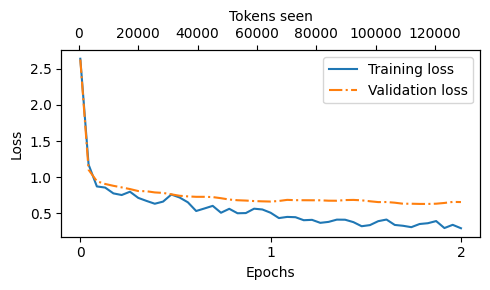

In [27]:
from previous_chapter import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

손실 그래프는 모델이 효과적으로 훈련하고 있다는 것을 나타내지만, 가장 중요한 것은 응답 품질과 정확성 측면에서 본 성능이다. 따라서 응답을 추출하고 품질을 평가하고 정량화할 수 있는 포맷으로 저장해본다.

## 7.7 응답을 추출하여 저장하기
지시 데이터셋의 훈련 세트에서 LLM을 미세 튜닝했으므로 이제 테스트 세트에서 모델의 성능을 평가할 준비가 되었다.

먼저 테스트 세트에 있는 입력에 대해 모델이 생성한 응답을 추출하여 수동으로 분석한다. 그 다음 LLM을 평가하여 응답의 품질을 정량화한다.

generate 함수를 사용하여 응답 추출 스텝을 수행한다. 그런 다음 테스트 세트에 있는 처음 3개의 항목에 대해 모델의 응답과 기대되는 응답을 비교하기 쉽도록 함께 출력한다.

In [29]:
from previous_chapter import (generate, text_to_token_ids, token_ids_to_text)

torch.manual_seed(123)
for entry in test_data[:3]: # 처음 3개의 테스트 세트 샘플을 순회한다.
  input_text = format_input(entry)
  token_ids = generate(
      model=model,
      idx = text_to_token_ids(input_text, tokenizer).to(device),
      max_new_tokens=256,
      context_size = BASE_CONFIG["context_length"],
      eos_id=50256
  )
  generated_text = token_ids_to_text(token_ids, tokenizer)

  response_text = (
      generated_text[len(input_text):]
      .replace("### Response:", "")
      .strip()
  )

  print(input_text)
  print(f"\n올바른 응답:\n>> {entry['output']}")
  print(f"\n모델 응답:\n>> {response_text.strip()}")
  print("------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

올바른 응답:
>> The car is as fast as lightning.

모델 응답:
>> The car is as fast as a bullet.
------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

올바른 응답:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

모델 응답:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

올바른 응답:
>> Jane Austen.

모델 응답:
>> The author of 'Pride and Prejudice' is Jane Austen.
------------------------------------

AlpacaEval의 방식을 따라서 다른 LLM을 사용해 미세 튜닝된 모델의 응답을 평가해보자.

이 평가를 위한 응답을 준비하기 위해 test_data 딕셔너리에 생성된 모델 응답을 추가하여 instruction-data-with-response.json 파일에 저장한다.

다음 코드는 이전과 동일하게 generate 함수를 사용하지만 이제 전체 test_data를 순회한다. 또한 모델 응답을 출력하지 않고 test_data 딕셔너리에 추가한다.

In [30]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
  input_text = format_input(entry)

  token_ids = generate(
      model=model,
      idx=text_to_token_ids(input_text, tokenizer).to(device),
      max_new_tokens=256,
      context_size=BASE_CONFIG["context_length"],
      eos_id=50256
  )
  generated_text = token_ids_to_text(token_ids, tokenizer)

  response_text = (
      generated_text[len(input_text):]
      .replace("### Response:", "")
      .strip()
  )

  test_data[i]["model_response"] = response_text

with open("instruction-data-with-response.json", "w") as file:
  json.dump(test_data, file, indent=4)

100%|██████████| 110/110 [01:27<00:00,  1.26it/s]


In [31]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


## 7.8 미세 튜닝된 LLM 평가하기
앞서 테스트 세트에 있는 샘플 3개에 대한 응답을 확인하여 미세 튜닝된 모델의 성능을 판단했다. 이를 보고 모델의 성능에 대해 감을 잡을 수 있지만 이 방식으로 많은 응답을 처리할 수 없다. 따라서 더 큰 LLm으로 미세 튜닝된 LLM의 응답을 자동으로 평가하는 방법을 구현한다.

테스트 세트 응답을 자동으로 평가하기 위해 메타 AI에서 개발한 80억 개 파라미터 규모의 Llama3 모델의 지시 미세 튜닝된 버전을 사용한다.

Ollama를 사용해 테스트 세트 응답을 평가하기 전에 Ollama 세션이 올바르게 실행되는지를 확인한다.

In [39]:
# =========================================================
# 1. Ollama 설치
# =========================================================

!apt-get update -qq
!apt-get install -y zstd pciutils
!curl -fsSL https://ollama.com/install.sh | sh


# =========================================================
# 2. Ollama 서버 실행
# =========================================================

import os
import subprocess
import time
import requests


OLLAMA_URL = "http://127.0.0.1:11434"
MODEL_NAME = "llama3"


def is_ollama_running():
    try:
        response = requests.get(
            f"{OLLAMA_URL}/api/tags",
            timeout=3
        )

        return response.status_code == 200

    except requests.RequestException:
        return False


if not is_ollama_running():
    log_file = open("/content/ollama.log", "w")

    ollama_process = subprocess.Popen(
        ["ollama", "serve"],
        stdout=log_file,
        stderr=subprocess.STDOUT
    )

    for _ in range(30):
        if is_ollama_running():
            break

        time.sleep(1)


if not is_ollama_running():
    print("Ollama 로그:")

    if os.path.exists("/content/ollama.log"):
        with open("/content/ollama.log", "r") as file:
            print(file.read())

    raise RuntimeError("Ollama 서버를 실행하지 못했습니다.")


print("Ollama 실행:", is_ollama_running())


# =========================================================
# 3. Llama 3 다운로드
# =========================================================

subprocess.run(
    ["ollama", "pull", MODEL_NAME],
    check=True
)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pciutils is already the newest version (1:3.7.0-6).
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 166 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Ollama 실행: True


CompletedProcess(args=['ollama', 'pull', 'llama3'], returncode=0)

In [40]:
import json
import urllib.request


def query_model(
    prompt,
    model="llama3",
    url="http://localhost:11434/api/chat"
):
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }

    payload = json.dumps(data).encode("utf-8")

    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )

    request.add_header("Content-Type", "application/json")

    response_data = ""

    with urllib.request.urlopen(request) as response:
        while True:
            line = response.readline().decode("utf-8")

            if not line:
                break

            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data

In [41]:
model = "llama3"
result = query_model("What dp Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily eat plants and plant-based foods. Here's a breakdown of what llamas typically eat:

1. **Grasses**: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. **Hay**: Hay is a staple in many llama diets. They enjoy timothy hay, alfalfa hay, or other types of hay as a nutritious snack or supplement.
3. **Grain**: Llamas may be fed grains like oats, barley, or corn as an energy-rich treat or to help support their digestive health.
4. **Fruits and vegetables**: Many llamas enjoy fruits and veggies as treats or supplements. Some favorites include apples, carrots, sweet potatoes, and leafy greens like kale or spinach.
5. **Minerals**: Llamas need access to minerals like calcium, phosphorus, and salt to maintain strong bones and overall health.

In terms of specific feeding practices:

* Free-ranging llamas: These animals are allowed to roam freely in pastures or fields, where they can graze o

query_model 함수를 사용하여 미세 튜닝된 모델이 생성한 응답을 평가할 수 있으며, Llama 3 모델에게 참조로 제공된 테스트 세트 응답을 바탕으로 미세 튜닝된 모델의 응답을 0에서 100 사이의 척도로 평가하도록 요청할 수 있다.

이제 전체 test_data에 generate_model_scores 함수를 적용해보자.

In [42]:
def generate_model_scores(json_data, json_key, model="llama3"):
  scores =[]
  for entry in tqdm(json_data, desc="평가 항목"):
    prompt =(
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry[json_key]}` "
        f" on a scale from 0 to 100, where 100 is the best score. "
        f"Respond with the integer number only"
    )
    score = query_model(prompt, model)
    try:
      scores.append(int(score))
    except ValueError:
      print(f"점수로 변환할 수 없습니다: {score}")
      continue
  return scores

In [44]:
scores = generate_model_scores(test_data, "model_response")
print(f"\n평가 횟수: {len(test_data)}개 중 {len(scores)}개")
print(f"평균 점수: {sum(scores)/len(scores):.2f}\n")

평가 항목: 100%|██████████| 110/110 [01:17<00:00,  1.42it/s]


평가 횟수: 110개 중 110개
평균 점수: 46.90



평가 결과를 보면 미세 튜닝된 모델이 평균적으로 50점 이상을 달성한다.

모델의 성능을 더 향상시키기 위해서는 다음과 같은 전략을 살펴볼 수 있다.
- 미세 튜닝 과정에서 학습률, 배치 크기, 에포크 횟수 같은 하이퍼파라미터를 조정한다.
- 훈련 데이터셋의 크기를 증가시키거나 다양한 주제와 스타일을 포함하도록 샘플을 다양화한다.
- 모델의 응답을 더 효과적으로 안내하기 위해 다른 프롬프트나 지식 포맷을 실험한다.
- 복잡한 패턴을 감지하고 더 정확한 응답을 생성하는 능력을 가진 대규모 사전 훈련된 모델을 사용한다.